# Counties, districts, and how each one leans

First notebook on the [Open-Source-Election](https://github.com/903124/Open-Source-Election) data — Wikipedia-sourced election results tidied into CSVs by that repo's pipeline.

This notebook showcase hwo to get county and district boundary geometry, attach election numbers to the shapes and visualize it. "Lean" here is defined in section 2 — a two-party margin relative to the nation


In [1]:
import json
import re
import urllib.parse
import urllib.request
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

REPO = Path("../Open-Source-Election")   # cloned from github.com/903124/Open-Source-Election
if not (REPO / "data").exists():          # notebook lives inside the repo
    REPO = Path("..")
GEO = Path("data/geo")          # cached boundary files
SEED = 14                       # any int — change it, rerun, resample

pd.options.display.float_format = "{:.2f}".format
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11,
})

print("geopandas", gpd.__version__, "| pandas", pd.__version__)


geopandas 1.1.2 | pandas 2.2.3


## 1 · Geometry

Pull geometry and plot the county and distribution shapes.

In [2]:
ESRI = "https://services.arcgis.com/P3ePLMYs2RVChkJx/ArcGIS/rest/services"


def esri_geojson(service, page=2000, max_pages=10):
    """Page a Living Atlas feature service into a FeatureCollection dict."""
    url = f"{ESRI}/{service}/FeatureServer/0/query"
    feats, offset = [], 0
    for _ in range(max_pages):
        q = urllib.parse.urlencode(dict(
            where="1=1", outFields="*", outSR=4326, f="geojson",
            resultRecordCount=page, resultOffset=offset,
            maxAllowableOffset=0.005, geometryPrecision=5))
        req = urllib.request.Request(
            f"{url}?{q}", headers={"User-Agent": "lean-notebook/0.1"})
        with urllib.request.urlopen(req, timeout=180) as r:
            d = json.load(r)
        feats += d.get("features", [])
        more = d.get("exceededTransferLimit",
                     d.get("properties", {}).get("exceededTransferLimit"))
        if not more or not d.get("features"):
            break
        offset += page
    return {"type": "FeatureCollection", "features": feats}


def cached(fname, service):
    dest = GEO / fname
    if not dest.exists():
        dest.write_text(json.dumps(esri_geojson(service)))
    return dest


GEO.mkdir(parents=True, exist_ok=True)
districts = gpd.read_file(cached("cd119.geojson",
                                 "USA_119th_Congressional_Districts"))
counties = gpd.read_file(cached("counties_generalized.geojson",
                                "USA_Counties_Generalized_Boundaries"))

print(f"{len(districts)} district polygons, {len(counties)} county polygons")
districts.drop(columns="geometry").head(3)


441 district polygons, 3144 county polygons


,OBJECTID,DISTRICTID,STFIPS,CDFIPS,STATE_ABBR,NAME,LAST_NAME,PARTY,SQMI,STATE_NAME,Shape__Area,Shape__Length
0,1,0101,01,01,AL,Barry Moore,Moore,Republican,7335.82,Alabama,1.80,22.88
1,2,0102,01,02,AL,Shomari Figures,Figures,Democrat,9551.34,Alabama,2.35,15.28
2,3,0103,01,03,AL,Mike Rogers,Rogers,Republican,6870.28,Alabama,1.72,7.75


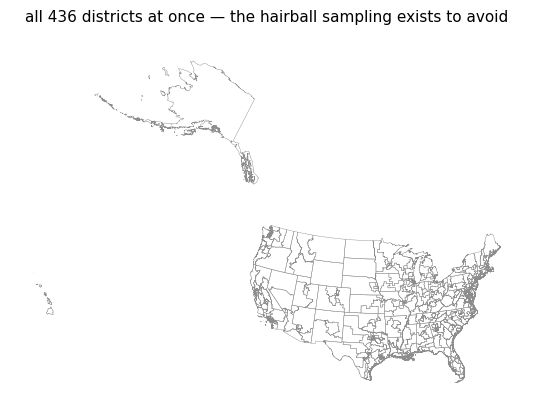

In [3]:
TERRITORIES = {"AS", "GU", "MP", "PR", "VI"}   # geometry ships them, wiki doesn't

fig, ax = plt.subplots(figsize=(7.5, 4.6))
states = districts[~districts["STATE_ABBR"].isin(TERRITORIES)]
states.to_crs(5070).plot(ax=ax, facecolor="none", edgecolor="0.55",
                         linewidth=0.3)
ax.set_axis_off()
ax.set_title(f"all {len(states)} districts at once — the hairball sampling "
             "exists to avoid");


## 2 · A lean for every county

The presidential CSV is candidate-level: one row per (county, candidate) using two-party D share = D / (D + R), then lean = county share − national share, in points. Positive = bluer than the country.

The national baseline comes from the county sums, then gets checked against the number the lean pipeline used (49.25 for 2024)

In [4]:
pres = pd.read_csv(REPO / "data/presidential/presidential_results_2024.csv")

DEM = {"democratic", "democratic-farmer-labor", "democratic-npl"}

def party_class(p):
    p = str(p or "").strip().lower()
    return "d" if p in DEM else "r" if p == "republican" else "o"

pres["pc"] = pres["party"].map(party_class)

# DC reports eight wards; fold them into the single county-equivalent
pres.loc[pres["state_code"] == "DC", "county"] = "District of Columbia"

votes = (pres.pivot_table(
            index=["state_code", "county", "subdivision_type"],
            columns="pc", values="votes", aggfunc="sum", fill_value=0)
            .reset_index())
votes["two_party"] = votes["d"] + votes["r"]
votes["d_share"] = 100 * votes["d"] / votes["two_party"]

national = 100 * votes["d"].sum() / votes["two_party"].sum()
lean = pd.read_csv(REPO / "data/district_lean/district_lean_2024.csv")
national_pipeline = lean["national_d_share_two_party_pct"].iloc[0]

print(f"national D two-party share — from county sums : {national:.2f}")
print(f"national D two-party share — pipeline's number : {national_pipeline:.2f}")

votes["lean"] = votes["d_share"] - national_pipeline
votes["lean_label"] = votes["lean"].map(
    lambda v: f"D+{v:.1f}" if v >= 0 else f"R+{-v:.1f}")

print(f"\n{len(votes)} county-equivalents")
votes["lean"].describe()


national D two-party share — from county sums : 49.25
national D two-party share — pipeline's number : 49.25

3143 county-equivalents


count   3143.00
mean     -16.92
std       15.91
min      -45.72
25%      -29.33
50%      -20.38
75%       -7.91
max       44.06
Name: lean, dtype: float64

### Matching names to polygons

Wiki tables identify counties by name; the geometry layer uses NAMELSAD-style names ("Autauga County", "Fairfax city"). The matcher tries a few rules per row, in order: raw name, suffixed form, census particle spellings ("De Witt" vs "DeWitt"), and city-vs-county candidates for Virginia, which names its 133 localities inconsistently. Whatever is still unmatched gets printed, not dropped.

In [5]:
SUFFIX_RE = re.compile(r"\s+(COUNTY|PARISH|BOROUGH|CENSUS AREA|CITY AND "
                       r"BOROUGH|CITY|MUNICIPALITY)$")
PARTICLE_RE = re.compile(r"\b(DE|DU|LA|LE|MC) ")


def norm(s):
    """Fold name spellings: no case, no apostrophes/okina, punctuation out."""
    for ch in "ʻ'’":
        s = s.replace(ch, "")
    s = re.sub(r"[^A-Za-z0-9 ]+", " ", s)
    return re.sub(r"\s+", " ", s).upper().strip()


def candidates(row):
    """Wiki name -> ordered list of geometry-name candidates."""
    n, t = str(row["county"]).strip(), row["subdivision_type"]
    if t == "Locality":                    # VA counties + independent cities
        stem = re.sub(r"\s+City$", "", n, flags=re.I)
        keys = [n, f"{stem} County", f"{stem} city", f"{n} County"]
    elif t == "Parish":
        keys = [n, f"{n} Parish"]
    elif t == "County" and not SUFFIX_RE.search(norm(n)):
        keys = [n, f"{n} County"]
    else:                                  # Alaska ships full forms
        keys = [n]
    return list(dict.fromkeys(keys))


counties = counties[counties["STATE_ABBR"] != "PR"]    # no wiki data for PR

lookup = {}
for i, r in counties.iterrows():
    k = norm(r["NAME"])
    lookup[(r["STATE_ABBR"], k)] = i
    lookup[(r["STATE_ABBR"], PARTICLE_RE.sub(r"\1", k))] = i  # De Witt = DeWitt

def match(row):
    for cand in candidates(row):
        k = (row["state_code"], norm(cand))
        if k in lookup:
            return lookup[k]
    return None

votes["geo_idx"] = votes.apply(match, axis=1)
matched = votes["geo_idx"].notna().sum()
print(f"matched {matched}/{len(votes)} county-equivalents "
      f"({100 * matched / len(votes):.1f}%)")
votes.loc[votes["geo_idx"].isna(), ["state_code", "county"]]


matched 3135/3143 county-equivalents (99.7%)


pc,state_code,county
309,CT,Fairfield
310,CT,Hartford
311,CT,Litchfield
312,CT,Middlesex
313,CT,New Haven
314,CT,New London
315,CT,Tolland
316,CT,Windham


In [6]:
county_geo = (votes.loc[votes["geo_idx"].notna()]
              .set_index("geo_idx")
              .join(counties[["NAME", "SQMI", "geometry"]], how="left")
              .reset_index())
county_geo = gpd.GeoDataFrame(county_geo, geometry="geometry",
                              crs=counties.crs)

LIM = np.ceil(county_geo["lean"].abs().max())          # symmetric color limits
norm_c = TwoSlopeNorm(vmin=-LIM, vcenter=0, vmax=LIM)
cmap = plt.colormaps["RdBu"]   # blue toward the D end, red toward the R end

print(f"{len(county_geo)} counties with geometry, lean range "
      f"[{county_geo['lean'].min():.1f}, {county_geo['lean'].max():.1f}]")
county_geo[["state_code", "county", "NAME", "lean", "lean_label"]].head(4)


3135 counties with geometry, lean range [-45.7, 44.1]


,state_code,county,NAME,lean,lean_label
0,AK,Aleutians East Borough,Aleutians East Borough,-18.98,R+19.0
1,AK,Aleutians West Census Area,Aleutians West Census Area,1.02,D+1.0
2,AK,Anchorage Municipality,Anchorage Municipality,1.48,D+1.5
3,AK,Bethel Census Area,Bethel Census Area,8.10,D+8.1


## 3 · Sixteen random counties, drawn to shape

Draw some random samples of counties shapes colored by lean.

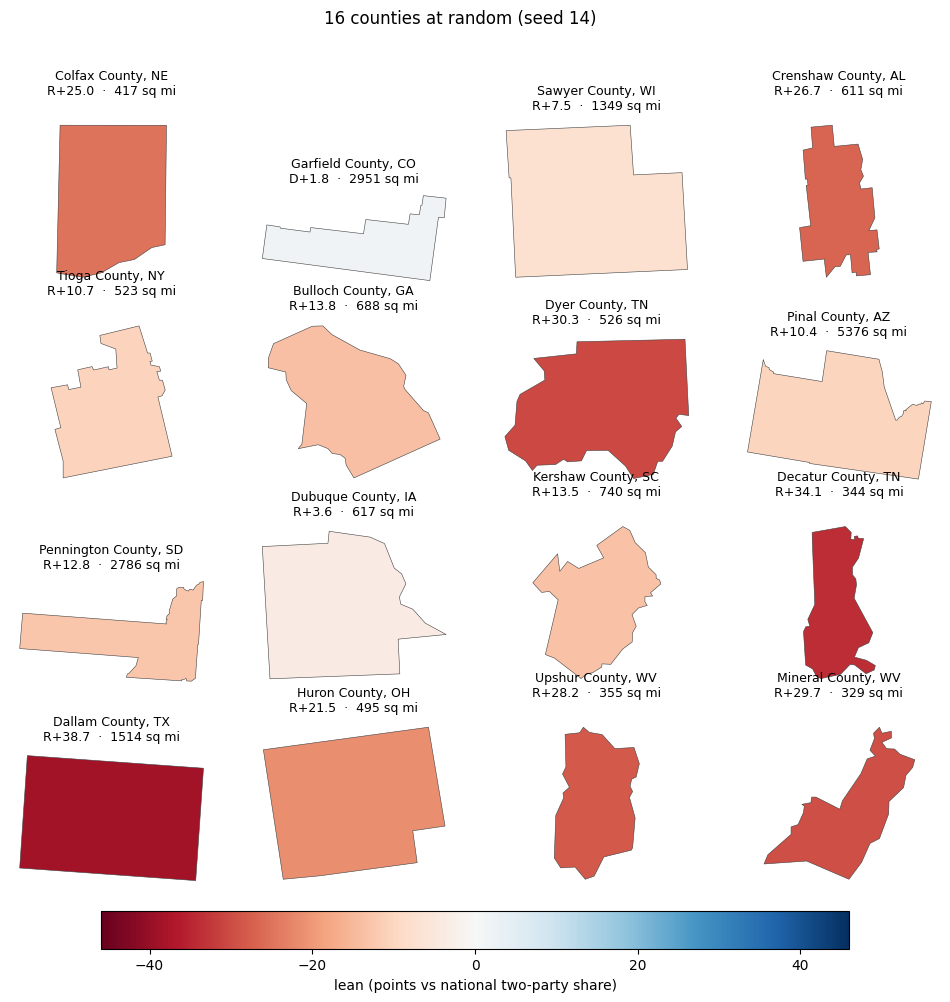

In [7]:
def lean_multiples(gdf, n, title_fmt, suptitle):
    """n sampled shapes in a grid, colored by lean on the shared scale."""
    sample = gdf.sample(n, random_state=SEED).to_crs(5070)
    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.7 * rows))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        gpd.GeoSeries([row.geometry], crs=sample.crs).plot(
            ax=ax, color=cmap(norm_c(row["lean"])), edgecolor="0.25",
            linewidth=0.4)
        ax.set_axis_off()
        ax.set_title(title_fmt(row), fontsize=9)
    for ax in axes.flat[len(sample):]:
        ax.set_visible(False)
    sm = plt.cm.ScalarMappable(norm=norm_c, cmap=cmap)
    fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.045,
                 pad=0.03, label="lean (points vs national two-party share)")
    fig.suptitle(suptitle, fontsize=12)
    return sample


sample_c = lean_multiples(
    county_geo, 16,
    title_fmt=lambda r: (f"{r['NAME']}, {r['state_code']}\n"
                         f"{r['lean_label']}  ·  {r['SQMI']:.0f} sq mi"),
    suptitle=f"16 counties at random (seed {SEED})");


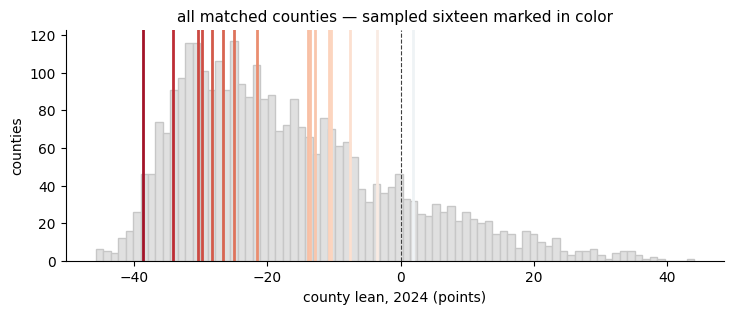

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 3))
ax.hist(county_geo["lean"], bins=80, color="0.88", edgecolor="0.78")
for v in sample_c["lean"]:
    ax.axvline(v, color=cmap(norm_c(v)), lw=2)
ax.axvline(0, color="0.25", lw=0.8, ls="--")
ax.set_xlabel("county lean, 2024 (points)")
ax.set_ylabel("counties")
ax.set_title("all matched counties — sampled sixteen marked in color");


## 4 · Congressional districts

Counties that are building blocks of districts are assembled into the congressional districts and similarly colored by lean

In [9]:
AT_LARGE = {"AK", "DE", "ND", "SD", "VT", "WY"}

def district_id(props):
    st, cdn = props["STATE_ABBR"], str(props["CDFIPS"])
    if st == "DC" or st in AT_LARGE:      # 98 = DC, 00 = at-large states
        return f"{st}-AL"
    return f"{st}-{cdn.zfill(2)}"

districts["district"] = districts.apply(district_id, axis=1)

cd_geo = districts.merge(
    lean[["district", "lean_pct", "lean_label"]], on="district", how="left")

print(f"{cd_geo['lean_pct'].notna().sum()} of {len(cd_geo)} polygons carry "
      "lean data")
print("no data:",
      sorted(cd_geo.loc[cd_geo["lean_pct"].isna(), "district"].tolist()))


436 of 441 polygons carry lean data
no data: ['AS-98', 'GU-98', 'MP-98', 'PR-98', 'VI-98']


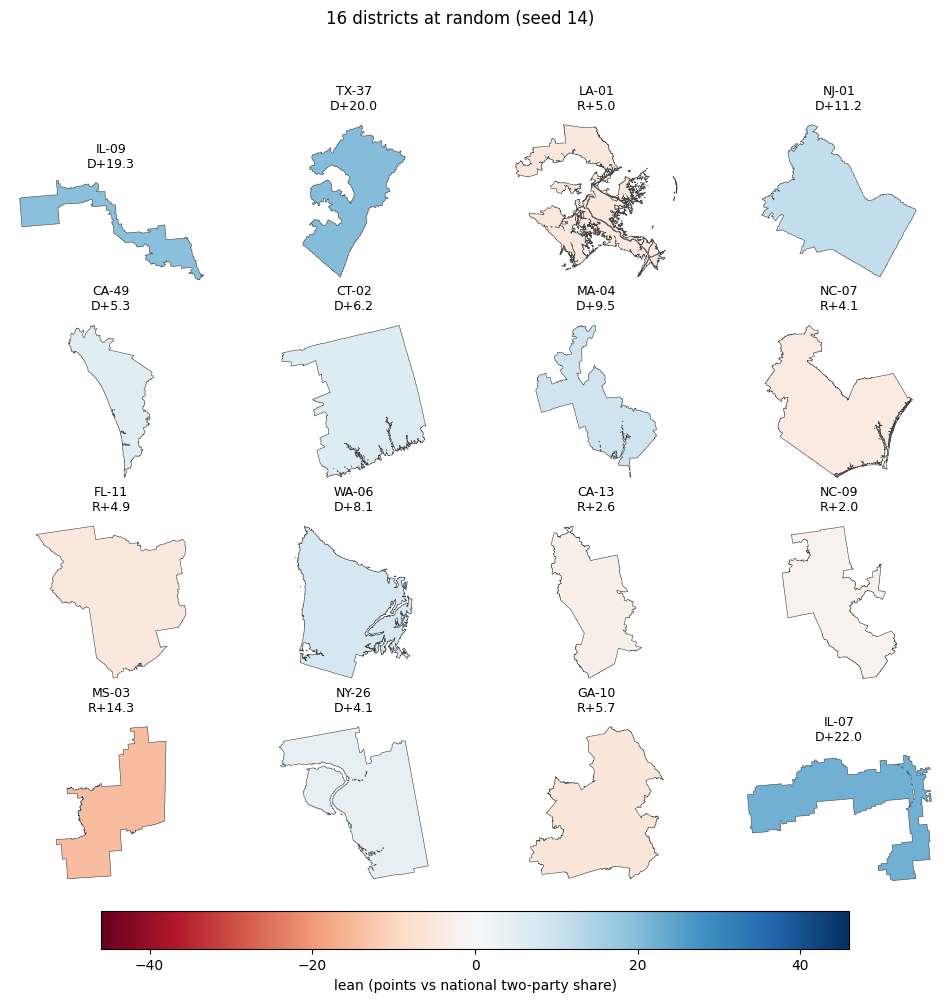

In [10]:
cd_matched = cd_geo[cd_geo["lean_pct"].notna()].copy()
cd_matched["lean"] = cd_matched["lean_pct"]

sample_d = lean_multiples(
    cd_matched, 16,
    title_fmt=lambda r: f"{r['district']}\n{r['lean_label']}",
    suptitle=f"16 districts at random (seed {SEED})");


median |lean| — counties: 21.3, districts: 10.0


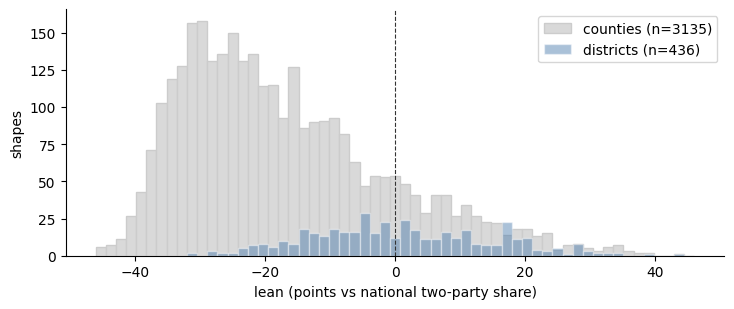

In [11]:
bins = np.linspace(-LIM, LIM, 60)
fig, ax = plt.subplots(figsize=(8.5, 3.2))
ax.hist(county_geo["lean"], bins=bins, color="0.85", edgecolor="0.8",
        label=f"counties (n={len(county_geo)})")
ax.hist(cd_matched["lean"], bins=bins, color="#4477aa", alpha=0.45,
        edgecolor="white", label=f"districts (n={len(cd_matched)})")
ax.axvline(0, color="0.2", lw=0.8, ls="--")
ax.set_xlabel("lean (points vs national two-party share)")
ax.set_ylabel("shapes")
ax.legend()
print(f"median |lean| — counties: {county_geo['lean'].abs().median():.1f}, "
      f"districts: {cd_matched['lean'].abs().median():.1f}");


## 5 · Assemble into States

Then the districts are assembled into states, and the state-level lean is computed from the district-level lean. The state-level lean is a weighted average of the district leans, weighted by the number of voters in each district.

,district,lean_label,lean
73,CO-01,D+29.6,29.60
74,CO-02,D+17.9,17.93
78,CO-06,D+11.6,11.65
79,CO-07,D+7.7,7.71
80,CO-08,R+0.9,-0.93
76,CO-04,R+1.0,-0.96
75,CO-03,R+4.2,-4.21
77,CO-05,R+4.3,-4.29


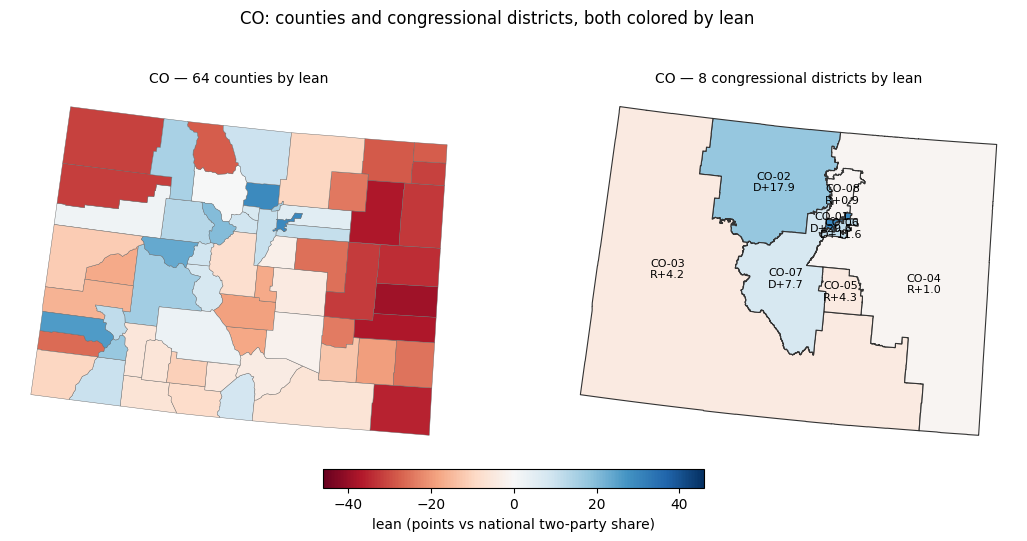

In [12]:
STATE = "CO"

state_counties = county_geo[county_geo["state_code"] == STATE].to_crs(5070)
state_cds = (cd_matched[cd_matched["STATE_ABBR"] == STATE]
             .sort_values("district").to_crs(5070))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
state_counties.plot(ax=axes[0], column="lean", cmap=cmap, norm=norm_c,
                    edgecolor="0.4", linewidth=0.3)
axes[0].set_title(f"{STATE} — {len(state_counties)} counties by lean",
                   fontsize=10)
axes[0].set_axis_off()

state_cds.plot(ax=axes[1], column="lean", cmap=cmap, norm=norm_c,
               edgecolor="0.2", linewidth=0.8)
for _, r in state_cds.iterrows():
    c = r.geometry.representative_point()
    axes[1].text(c.x, c.y, f"{r['district']}\n{r['lean_label']}",
                 ha="center", va="center", fontsize=8)
axes[1].set_title(f"{STATE} — {len(state_cds)} congressional districts by lean",
                   fontsize=10)
axes[1].set_axis_off()

sm = plt.cm.ScalarMappable(norm=norm_c, cmap=cmap)
fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.045,
             pad=0.04, label="lean (points vs national two-party share)")
fig.suptitle(f"{STATE}: counties and congressional districts, both colored by lean",
             fontsize=12)

state_cds[["district", "lean_label", "lean"]].sort_values("lean", ascending=False)


## Notes

- Geometry: 441 district and 3,144 county polygons from Esri's Census mirror, cached under `data/geo/`, EPSG:4326 → 5070 for plotting.
- Lean: 2024 presidential two-party margin vs national. County sums reproduce the pipeline's 49.25 baseline exactly.
- Name matching: 3,135 of 3,143 county-equivalents (99.7%). The 8 misses are Connecticut — geometry ships towns, the wiki export lists counties.
- Sampling: county draws skew red (≈ sampling land); districts don't. Median |lean| is 21.3 for counties vs 10.0 for districts.
- Colorado: Front Range districts at D+18 to D+30; plains and slope counties drive CO-03–05 to R+1 to R+4.

Known gaps: the Esri simplification drops small features; Connecticut's 8 name misses; territories (AS, GU, MP, PR, VI) have geometry but no wiki election data, so they stay out of the joins.